In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [182]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [183]:
with fits.open('astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17352/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17352/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17352/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

(-1.05, 0.55)

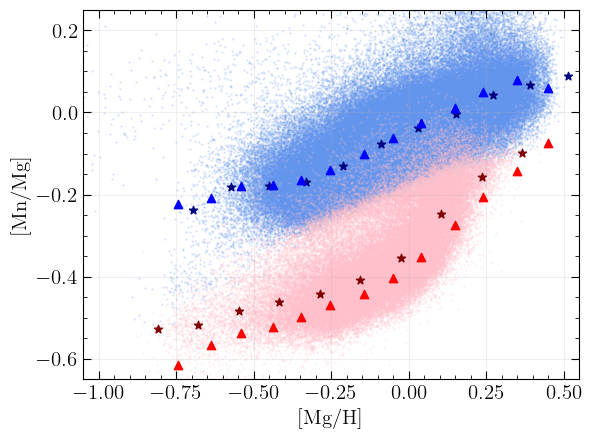

In [184]:
data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]


plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

In [185]:
data_low_alpha_org = data_low_alpha
data_high_alpha_org = data_high_alpha

In [186]:
N = 10000

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df

data_low_alpha = downsample(data_low_alpha, N)
data_high_alpha = downsample(data_high_alpha, N)

print(len(data_high_alpha_org))
print(len(data_low_alpha_org))

print(len(data_high_alpha))
print(len(data_low_alpha))

68308
191737
10000
10000


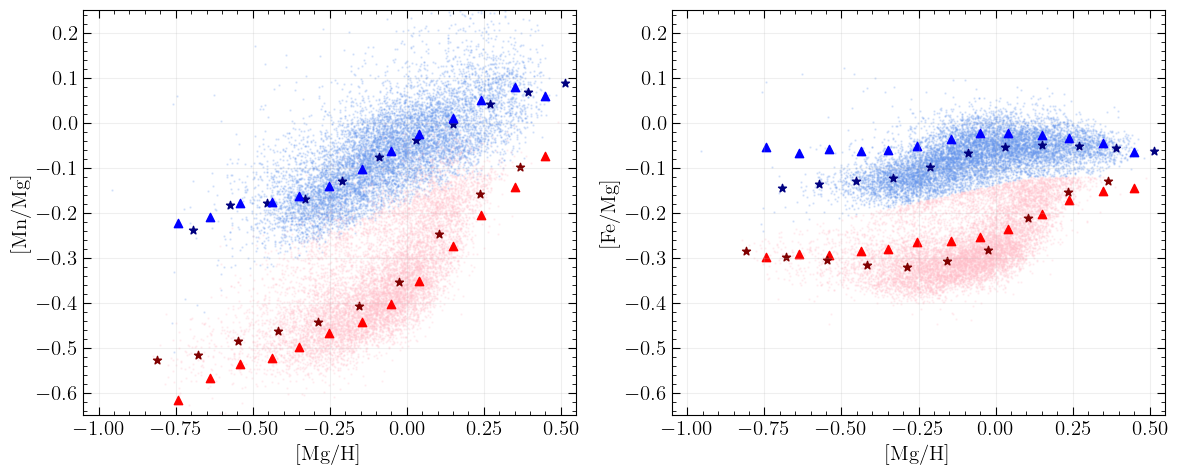

In [187]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# Rise + Fall SFR 

In [188]:
def make_mock_pop(galaxy_model, sfr, n_samples=1000, error_on_met = 0.05):
    mstars = sfr/galaxy_model.tau_star_arr[0] * dt
    cdf_mstars = np.cumsum(mstars)/np.sum(mstars)
    u = np.random.rand(n_samples)
    sampled = np.searchsorted(cdf_mstars, u)
    gal_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
    gal_df['O_H'] = np.random.normal(loc=galaxy_model.O_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_O'] = np.random.normal(loc=galaxy_model.Fe_O[sampled], scale = error_on_met, size=n_samples)
    gal_df['Mn_O'] = np.random.normal(loc=galaxy_model.Mn_O[sampled], scale = error_on_met, size=n_samples)
    gal_df['O_Fe'] = np.random.normal(loc=galaxy_model.O_Fe[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)

    return gal_df

dt =  0.014013913913913914


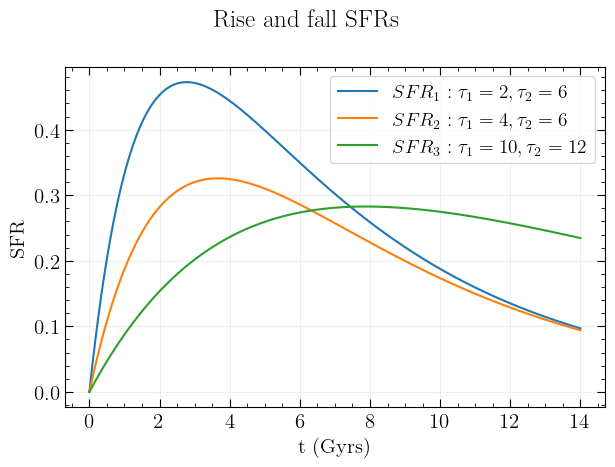

In [189]:
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)

tau_1s = [2, 4, 10]
tau_2s = [6, 6, 12]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])

plt.plot(t_array, sfr_1, label = rf'$SFR_1 : \tau_1 = {tau_1s[0]}, \tau_2 = {tau_2s[0]}$')
plt.plot(t_array, sfr_2, label = rf'$SFR_2 : \tau_1 = {tau_1s[1]}, \tau_2 = {tau_2s[1]}$')
plt.plot(t_array, sfr_3, label = rf'$SFR_3 : \tau_1 = {tau_1s[2]}, \tau_2 = {tau_2s[2]}$')

plt.grid('True', alpha = 0.2)
plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

plt.suptitle("Rise and fall SFRs")
plt.tight_layout()

In [190]:
tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

gal1_rf_df = make_mock_pop(gal1_rf, sfr_1)
gal2_rf_df = make_mock_pop(gal2_rf, sfr_2)
gal3_rf_df = make_mock_pop(gal3_rf, sfr_3)

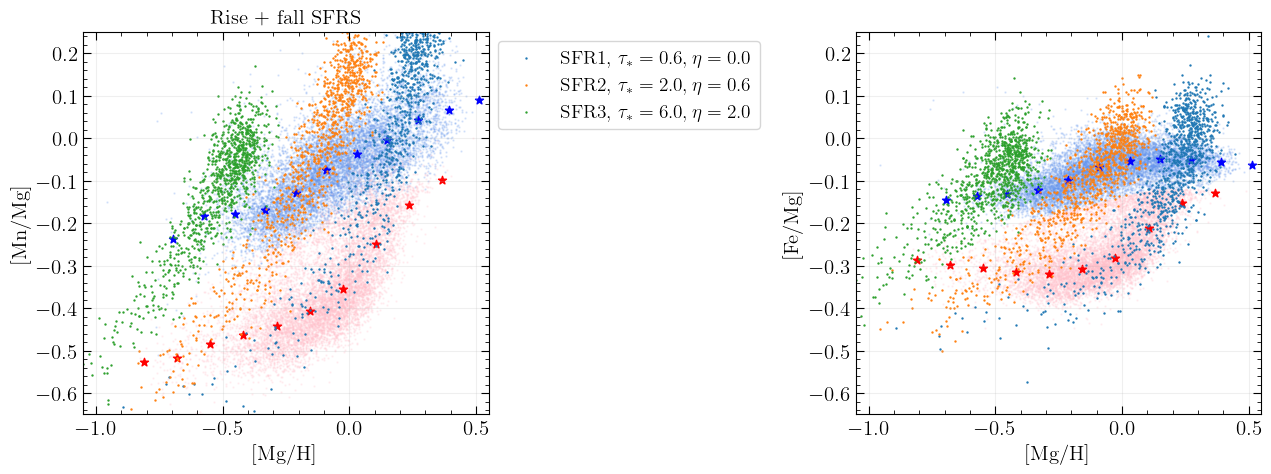

In [191]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Fe_O'], s = 0.5)

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# Rise + Fall + Cut off

dt =  0.014013913913913914


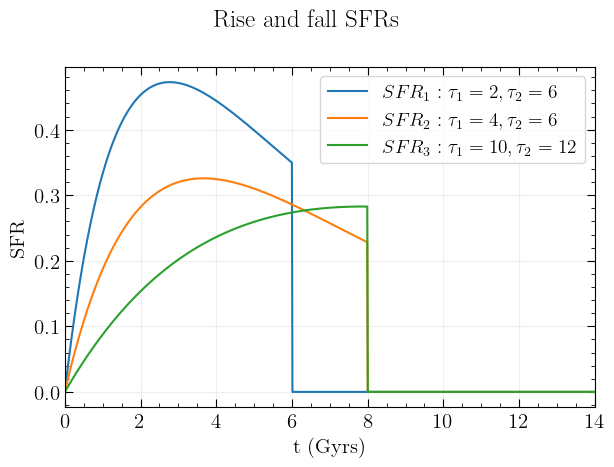

In [192]:
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)

cut_1 = t_array > 6
cut_2 = t_array > 8
cut_3 = t_array > 8

tau_1s = [2, 4, 10]
tau_2s = [6, 6, 12]
sfr_1_cut = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_1_cut[cut_1] = 1e-10
sfr_2_cut = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_2_cut[cut_2] = 1e-10
sfr_3_cut = rise_fall(t_array, tau_1s[2], tau_2s[2])
sfr_3_cut[cut_3] = 1e-10

plt.plot(t_array, sfr_1_cut, label = rf'$SFR_1 : \tau_1 = {tau_1s[0]}, \tau_2 = {tau_2s[0]}$')
plt.plot(t_array, sfr_2_cut, label = rf'$SFR_2 : \tau_1 = {tau_1s[1]}, \tau_2 = {tau_2s[1]}$')
plt.plot(t_array, sfr_3_cut, label = rf'$SFR_3 : \tau_1 = {tau_1s[2]}, \tau_2 = {tau_2s[2]}$')

plt.xlim(0,14)
plt.grid('True', alpha = 0.2)
plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

plt.suptitle("Rise and fall SFRs")
plt.tight_layout()

In [193]:
tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1_rfcut = evo.Galaxy(t_array=t_array, m_g_array=sfr_1_cut, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rfcut = evo.Galaxy(t_array=t_array, m_g_array=sfr_2_cut, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rfcut = evo.Galaxy(t_array=t_array, m_g_array=sfr_3_cut, tau_star=tau_stars_2024[2], eta = etas_2024[2])

gal1_rfcut_df = make_mock_pop(gal1_rfcut, sfr_1_cut, error_on_met=0.05)
gal2_rfcut_df = make_mock_pop(gal2_rfcut, sfr_2_cut, error_on_met=0.05)
gal3_rfcut_df = make_mock_pop(gal3_rfcut, sfr_3_cut, error_on_met=0.05)

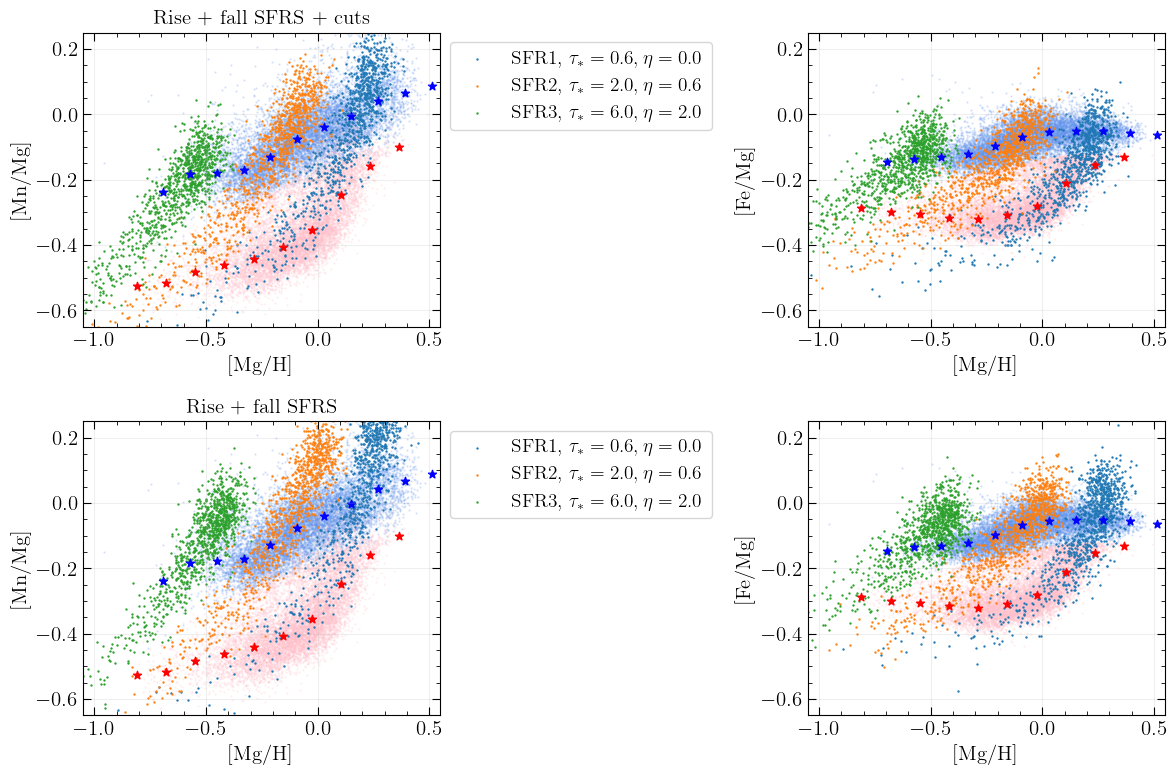

In [194]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)


plt.scatter(gal1_rfcut_df['O_H'], gal1_rfcut_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rfcut_df['O_H'], gal2_rfcut_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rfcut_df['O_H'], gal3_rfcut_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS + cuts')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(2,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(gal1_rfcut_df['O_H'], gal1_rfcut_df['Fe_O'], s = 0.5)
plt.scatter(gal2_rfcut_df['O_H'], gal2_rfcut_df['Fe_O'], s = 0.5)
plt.scatter(gal3_rfcut_df['O_H'], gal3_rfcut_df['Fe_O'], s = 0.5)

plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.subplot(2,2,3)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')

plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(2,2,4)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Fe_O'], s = 0.5)

plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.tight_layout()

# Scale Mn cc production by * 0.8

In [195]:
def make_mock_pop_scaled(galaxy_model, sfr, n_samples=1000, error_on_met = 0.05):
    mstars = sfr/galaxy_model.tau_star_arr[0] * dt
    cdf_mstars = np.cumsum(mstars)/np.sum(mstars)
    u = np.random.rand(n_samples)
    sampled = np.searchsorted(cdf_mstars, u)
    gal_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H', 'Mn_H'])
    gal_df['O_H'] = np.random.normal(loc=galaxy_model.O_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_O'] = np.random.normal(loc=galaxy_model.Fe_O[sampled], scale = error_on_met, size=n_samples)
    Z_Mn_scaled = galaxy_model.compute_z_X(cc_ref_element="O-scaled", Ia_ref_element = "Fe-scaled")
    Mn_H_scaled = galaxy_model.ratio_to_sun(Z_Mn_scaled, galaxy_model.SolarMn)
    Mn_O_scaled = Mn_H_scaled - galaxy_model.O_H

    gal_df['Mn_H'] = np.random.normal(loc=Mn_H_scaled[sampled], scale = error_on_met, size=n_samples)
    gal_df['Mn_O'] = np.random.normal(loc=Mn_O_scaled[sampled], scale = error_on_met, size=n_samples)

    gal_df['O_Fe'] = np.random.normal(loc=galaxy_model.O_Fe[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)

    return gal_df

In [196]:
tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1_rf_scaled = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf_scaled = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf_scaled = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

gal1_rf_scaled_df = make_mock_pop_scaled(gal1_rf, sfr_1)
gal2_rf_scaled_df = make_mock_pop_scaled(gal2_rf, sfr_2)
gal3_rf_scaled_df = make_mock_pop_scaled(gal3_rf, sfr_3)

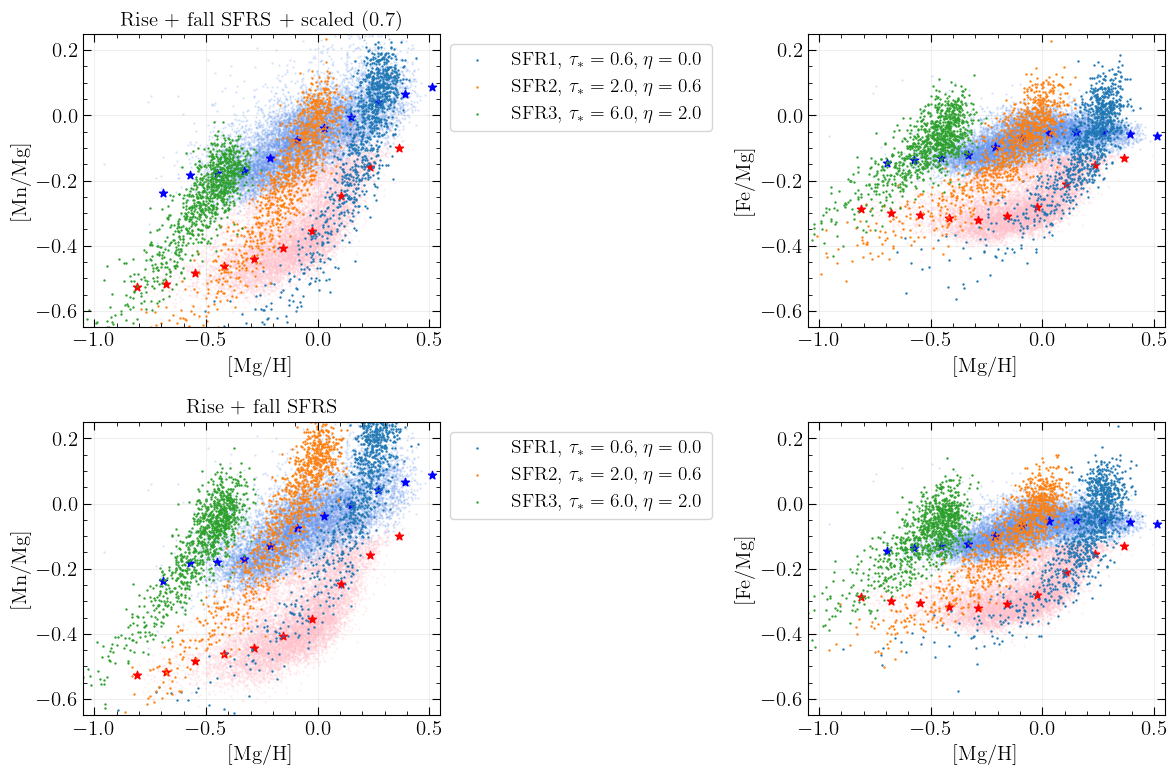

In [197]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_scaled_df['O_H'], gal1_rf_scaled_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_scaled_df['O_H'], gal2_rf_scaled_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_scaled_df['O_H'], gal3_rf_scaled_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS + scaled (0.7)')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(2,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_scaled_df['O_H'], gal1_rf_scaled_df['Fe_O'], s = 0.5)
plt.scatter(gal2_rf_scaled_df['O_H'], gal2_rf_scaled_df['Fe_O'], s = 0.5)
plt.scatter(gal3_rf_scaled_df['O_H'], gal3_rf_scaled_df['Fe_O'], s = 0.5)

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)



plt.subplot(2,2,3)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Mn_O'], s = 0.5, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Mn_O'], s = 0.5, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Mn_O'], s = 0.5, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(2,2,4)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Fe_O'], s = 0.5)
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Fe_O'], s = 0.5)

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.tight_layout()

# corner plots

In [215]:
len(gal1_rf_df)

1000

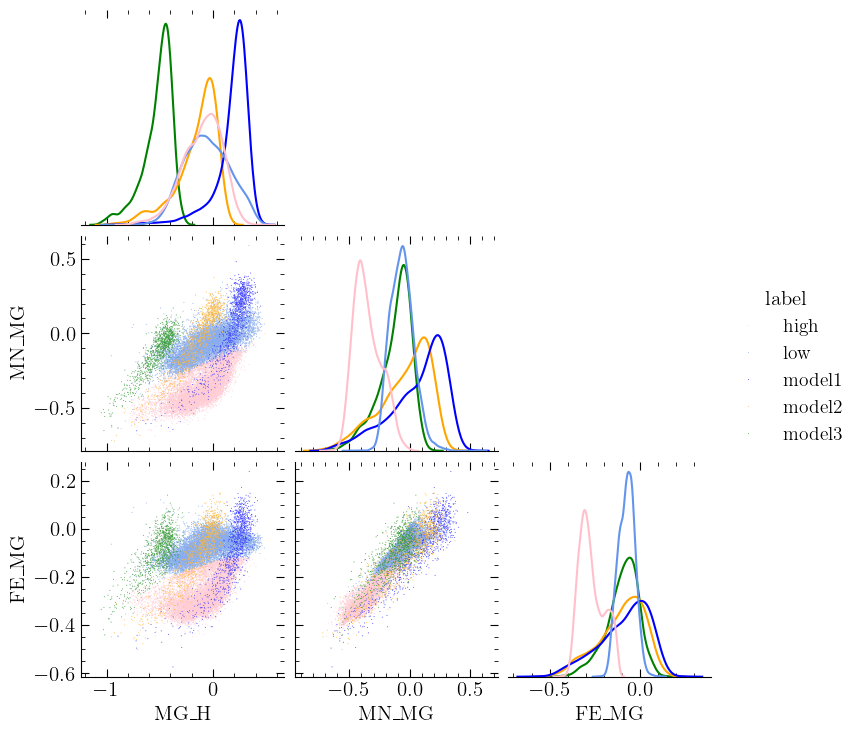

In [235]:
data_high_alpha_down = downsample(data_high_alpha_org, N=10000)
data_low_alpha_down = downsample(data_low_alpha_org, N=10000)

data_high_alpha_down['label'] = 'high'
data_low_alpha_down['label'] = 'low'

combined_data = pd.concat([data_high_alpha_down, data_low_alpha_down], ignore_index=True)

# --- Fix: rename inside the model DFs ---
gal1_rf_df['label'] = 'model1'
gal2_rf_df['label'] = 'model2'
gal3_rf_df['label'] = 'model3'

combined_models = pd.concat([gal1_rf_df, gal2_rf_df, gal3_rf_df], ignore_index=True)

combined_models['MG_H']   = combined_models['O_H']
combined_models['MN_MG']  = combined_models['Mn_O']
combined_models['FE_MG']  = combined_models['Fe_O']
combined_models['FE_H']   = combined_models['Fe_H']

# --- FIX HERE ---
combined_all = pd.concat(
    [combined_data, combined_models],   # <-- use combined_models
    ignore_index=True
)

combined_all = combined_all[(combined_all['MG_H'] < 0.55) & (combined_all['MG_H'] > -1.05)]
combined_all = combined_all[(combined_all['FE_MG'] < 0.25) & (combined_all['FE_MG'] > -0.65)]

# --- Plot ---
sns.pairplot(
    combined_all,
    vars=['MG_H', 'MN_MG', 'FE_MG'],
    diag_kind='kde',
    corner=True,
    hue='label',
    palette={
        'high':'pink', 
        'low':'cornflowerblue',
        'model1':'blue',
        'model2':'orange',
        'model3':'green'
    },
    plot_kws=dict(s=0.5, alpha=0.8),
    diag_kws=dict(common_norm=False, fill=False)
)


plt.title('')
plt.show()


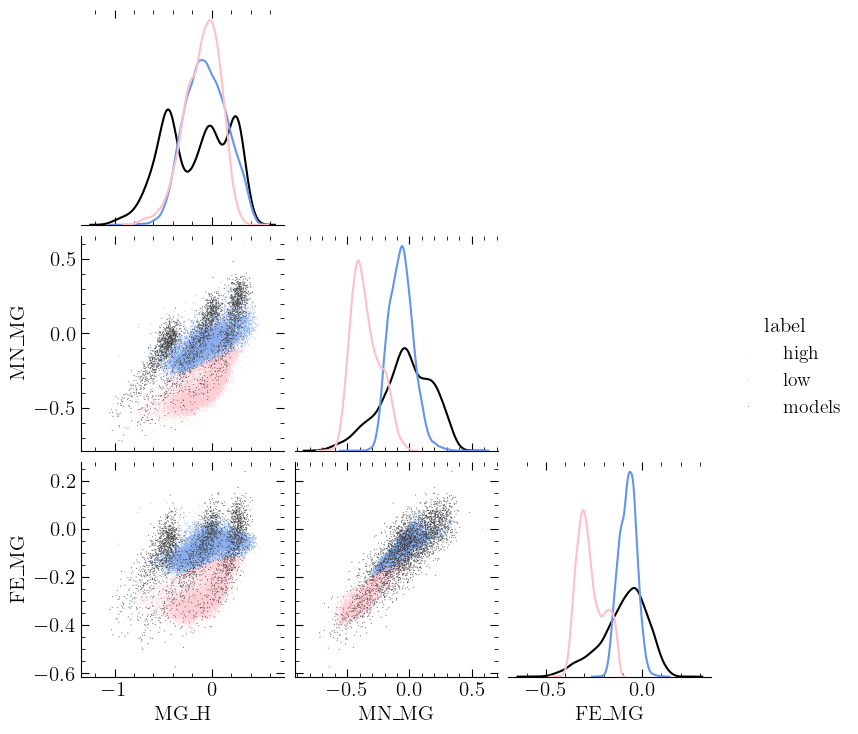

In [239]:
data_high_alpha_down = downsample(data_high_alpha_org, N=10000)
data_low_alpha_down = downsample(data_low_alpha_org, N=10000)

data_high_alpha_down['label'] = 'high'
data_low_alpha_down['label'] = 'low'

combined_data = pd.concat([data_high_alpha_down, data_low_alpha_down], ignore_index=True)

combined_models = pd.concat([gal1_rf_df, gal2_rf_df, gal3_rf_df], ignore_index=True)
combined_models['label'] = 'models'

combined_models['MG_H']   = combined_models['O_H']
combined_models['MN_MG']  = combined_models['Mn_O']
combined_models['FE_MG']  = combined_models['Fe_O']
combined_models['FE_H']   = combined_models['Fe_H']

# --- FIX HERE ---
combined_all = pd.concat(
    [combined_data, combined_models],   # <-- use combined_models
    ignore_index=True
)

combined_all = combined_all[(combined_all['MG_H'] < 0.55) & (combined_all['MG_H'] > -1.05)]
combined_all = combined_all[(combined_all['FE_MG'] < 0.25) & (combined_all['FE_MG'] > -0.65)]

# --- Plot ---
sns.pairplot(
    combined_all,
    vars=['MG_H', 'MN_MG', 'FE_MG'],
    diag_kind='kde',
    corner=True,
    hue='label',
    palette={
        'high':'pink', 
        'low':'cornflowerblue',
        'models':'black'
    },
    plot_kws=dict(s=0.5, alpha=0.8),
    diag_kws=dict(common_norm=False, fill=False)
)


plt.title('')
plt.show()


In [284]:
mg_h_all = np.concatenate([data_low_alpha_org['MG_H'], data_high_alpha_org['MG_H']])

# Define 10 equal-width bins across the combined range
bin_edges = np.linspace(mg_h_all.min(), mg_h_all.max(), 11)  # 10 bins → 11 edges
data_low_alpha['MG_H_bin']  = pd.cut(data_low_alpha['MG_H'], bins=bin_edges, labels=False)
data_high_alpha['MG_H_bin'] = pd.cut(data_high_alpha['MG_H'], bins=bin_edges, labels=False)


In [285]:
# Low-alpha subsets
low_alpha_low_z  = data_low_alpha[data_low_alpha['zmax'] < 0.5]
low_alpha_mid_z  = data_low_alpha[(data_low_alpha['zmax'] >= 0.5) & (data_low_alpha['zmax'] < 1)]
low_alpha_high_z = data_low_alpha[data_low_alpha['zmax'] >= 1]

# High-alpha subsets
high_alpha_low_z  = data_high_alpha[data_high_alpha['zmax'] < 0.5]
high_alpha_mid_z  = data_high_alpha[(data_high_alpha['zmax'] >= 0.5) & (data_high_alpha['zmax'] < 1)]
high_alpha_high_z = data_high_alpha[data_high_alpha['zmax'] >= 1]

bin_idx = 5  # change to any bin 0–9

# Low-alpha bin 1 subsets
low_alpha_low_z_bin1  = low_alpha_low_z[low_alpha_low_z['MG_H_bin'] == bin_idx]
low_alpha_mid_z_bin1  = low_alpha_mid_z[low_alpha_mid_z['MG_H_bin'] == bin_idx]
low_alpha_high_z_bin1 = low_alpha_high_z[low_alpha_high_z['MG_H_bin'] == bin_idx]

# High-alpha bin 1 subsets
high_alpha_low_z_bin1  = high_alpha_low_z[high_alpha_low_z['MG_H_bin'] == bin_idx]
high_alpha_mid_z_bin1  = high_alpha_mid_z[high_alpha_mid_z['MG_H_bin'] == bin_idx]
high_alpha_high_z_bin1 = high_alpha_high_z[high_alpha_high_z['MG_H_bin'] == bin_idx]

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17352/132971028.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


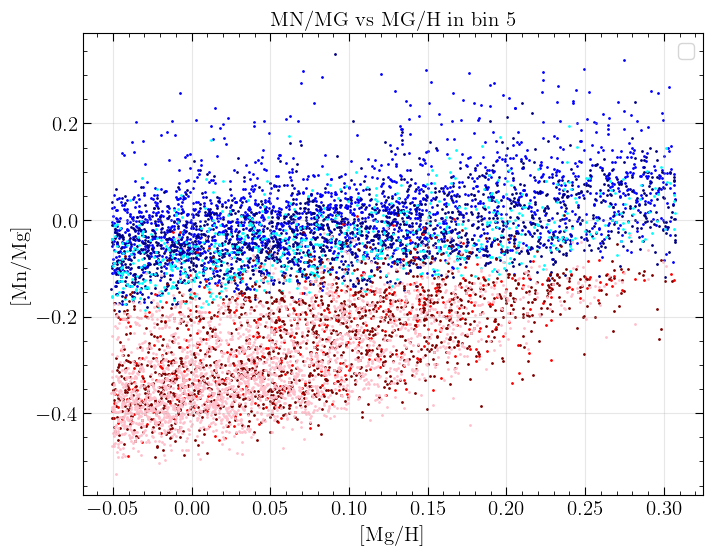

In [286]:
plt.figure(figsize=(8,6))
plt.scatter(low_alpha_low_z_bin1['MG_H'], low_alpha_low_z_bin1['MN_MG'], color='blue', s = 1)
plt.scatter(low_alpha_mid_z_bin1['MG_H'], low_alpha_mid_z_bin1['MN_MG'], color='navy', s = 1)
plt.scatter(low_alpha_high_z_bin1['MG_H'], low_alpha_high_z_bin1['MN_MG'], color='cyan', s = 1)

plt.scatter(high_alpha_low_z_bin1['MG_H'], high_alpha_low_z_bin1['MN_MG'], color='red', s = 1)
plt.scatter(high_alpha_mid_z_bin1['MG_H'], high_alpha_mid_z_bin1['MN_MG'], color='maroon', s = 1)
plt.scatter(high_alpha_high_z_bin1['MG_H'], high_alpha_high_z_bin1['MN_MG'], color='pink', s = 1)

plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.title(f'MN/MG vs MG/H in bin {bin_idx}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


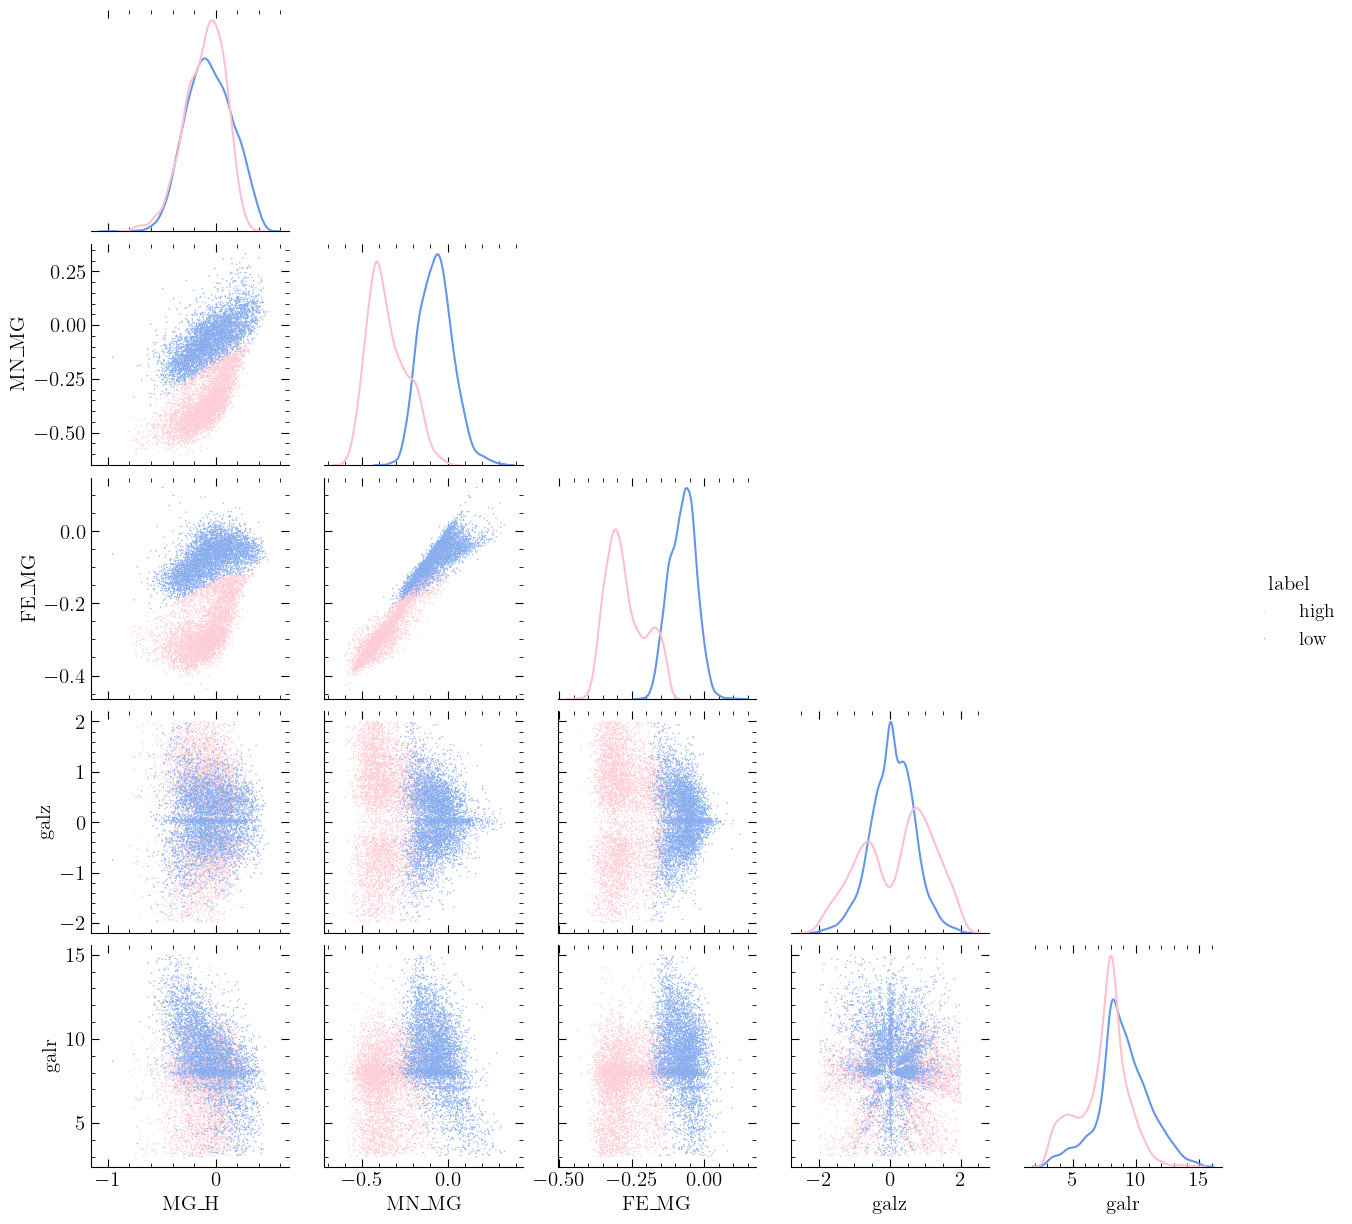

In [298]:
data_high_alpha_down = downsample(data_high_alpha_org, N=5000)
data_low_alpha_down = downsample(data_low_alpha_org, N=5000)

data_high_alpha_down['label'] = 'high'
data_low_alpha_down['label'] = 'low'

combined_data = pd.concat([data_high_alpha_down, data_low_alpha_down], ignore_index=True)

combined_models = pd.concat([gal1_rf_df, gal2_rf_df, gal3_rf_df], ignore_index=True)
combined_models['label'] = 'models'

combined_models['MG_H']   = combined_models['O_H']
combined_models['MN_MG']  = combined_models['Mn_O']
combined_models['FE_MG']  = combined_models['Fe_O']
combined_models['FE_H']   = combined_models['Fe_H']

# --- FIX HERE ---
combined_all = pd.concat(
    [combined_data, combined_models],   # <-- use combined_models
    ignore_index=True
)

combined_data = combined_data[(combined_data['MG_H'] < 0.55) & (combined_data['MG_H'] > -1.05)]
combined_data = combined_data[(combined_data['FE_MG'] < 0.25) & (combined_data['FE_MG'] > -0.65)]

# --- Plot ---
sns.pairplot(
    combined_data,
    vars=['MG_H', 'MN_MG', 'FE_MG', 'galz', 'galr'],
    diag_kind='kde',
    corner=True,
    hue='label',
    palette={
        'high':'pink', 
        'low':'cornflowerblue',
    },
    plot_kws=dict(s=1, alpha=0.8),
    diag_kws=dict(common_norm=False, fill=False)
)


plt.title('')
plt.show()
